# Orbit saddle-point times vs momentum

Plots the three solved saddle-point times from `OrbitFinder`'s Helium RESI run
(`helium_resi_cross.inp`) as a function of momentum, for both the short and long
orbit branches.

Column mapping in the raw `.shortorbit`/`.longorbit` files
(`p_long p_trans t1_re t1_im t2_re t2_im t3_re t3_im`):
- **t1** = electron 1's ionisation time (tunnelling into the continuum)
- **t2** = electron 1's recollision time (return to the core, where energy is handed to electron 2)
- **t3** = electron 2's ionisation time (tunnels out after being excited at recollision)

This is the diagnostic used to spot the branch-selection jump found while debugging the
Frankenstein combination: `t2`'s real part jumps to a *different* branch for $p_{long}>0$
vs $p_{long}<0$ at the same grid row, which is not a simple mirror image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "/workspaces/CQSFA/OrbitFinder/TestingSuite/results"
SHORT_FILE = f"{RESULTS_DIR}/helium_resi_cross.inp_Range_29X29_channel:0.shortorbit"
LONG_FILE = f"{RESULTS_DIR}/helium_resi_cross.inp_Range_29X29_channel:0.longorbit"


def load_times(fname):
    rows = np.loadtxt(fname)
    p_long, p_trans = rows[:, 0], rows[:, 1]
    t1 = rows[:, 2] + 1j * rows[:, 3]
    t2 = rows[:, 4] + 1j * rows[:, 5]
    t3 = rows[:, 6] + 1j * rows[:, 7]
    return p_long, p_trans, t1, t2, t3


pl_s, pt_s, t1_s, t2_s, t3_s = load_times(SHORT_FILE)
pl_l, pt_l, t1_l, t2_l, t3_l = load_times(LONG_FILE)

p_long_axis = np.unique(np.round(pl_s, 3))
p_trans_axis = np.unique(np.round(pt_s, 3))
print(f"grid: {len(p_long_axis)}x{len(p_trans_axis)}, p_long in [{p_long_axis.min():.3f},{p_long_axis.max():.3f}]")

grid: 29x29, p_long in [-4.315,4.315]


## 1D slice at $p_{trans}=0$: time vs $p_{long}$

The cleanest view of how each saddle time evolves with momentum along the polarisation axis.

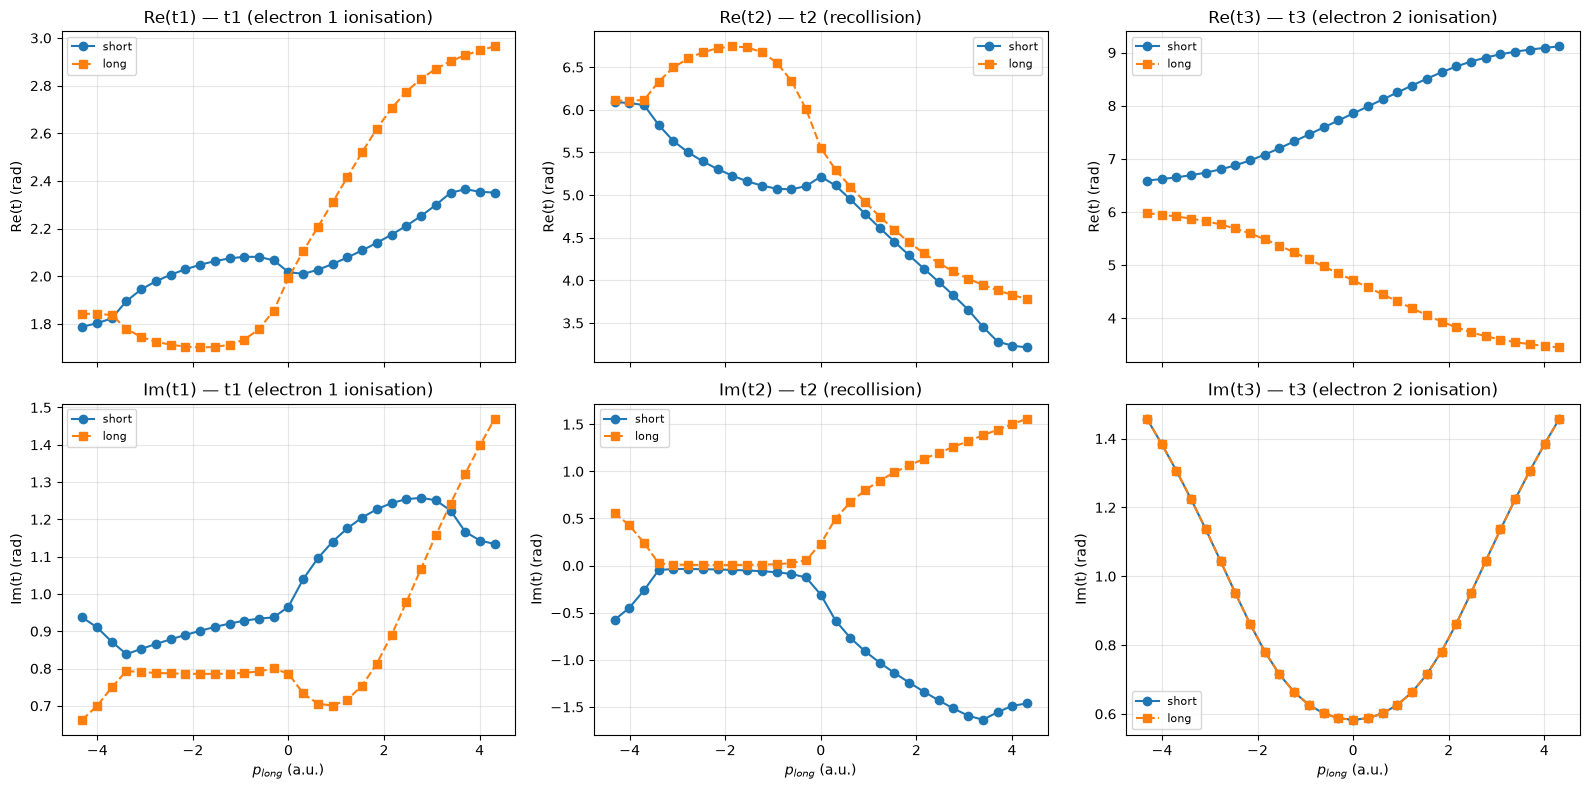

In [2]:
def slice_at_ptrans0(p_long, p_trans, values, decimals=3):
    mask = np.isclose(np.round(p_trans, decimals), 0.0)
    order = np.argsort(p_long[mask])
    return p_long[mask][order], values[mask][order]

times = [("t1 (electron 1 ionisation)", t1_s, t1_l), ("t2 (recollision)", t2_s, t2_l), ("t3 (electron 2 ionisation)", t3_s, t3_l)]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for col, (label, ts, tl) in enumerate(times):
    p_s, v_s = slice_at_ptrans0(pl_s, pt_s, ts)
    p_l, v_l = slice_at_ptrans0(pl_l, pt_l, tl)

    axes[0, col].plot(p_s, v_s.real, "o-", label="short", color="tab:blue")
    axes[0, col].plot(p_l, v_l.real, "s--", label="long", color="tab:orange")
    axes[0, col].set_title(f"Re({label.split()[0]}) — {label}")
    axes[0, col].set_ylabel("Re(t) (rad)")

    axes[1, col].plot(p_s, v_s.imag, "o-", label="short", color="tab:blue")
    axes[1, col].plot(p_l, v_l.imag, "s--", label="long", color="tab:orange")
    axes[1, col].set_title(f"Im({label.split()[0]}) — {label}")
    axes[1, col].set_ylabel("Im(t) (rad)")
    axes[1, col].set_xlabel(r"$p_{long}$ (a.u.)")

for ax in axes.flat:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2D maps: time vs $(p_{long}, p_{trans})$

Shows the full grid, so branch jumps that only appear away from $p_{trans}=0$ are visible too.

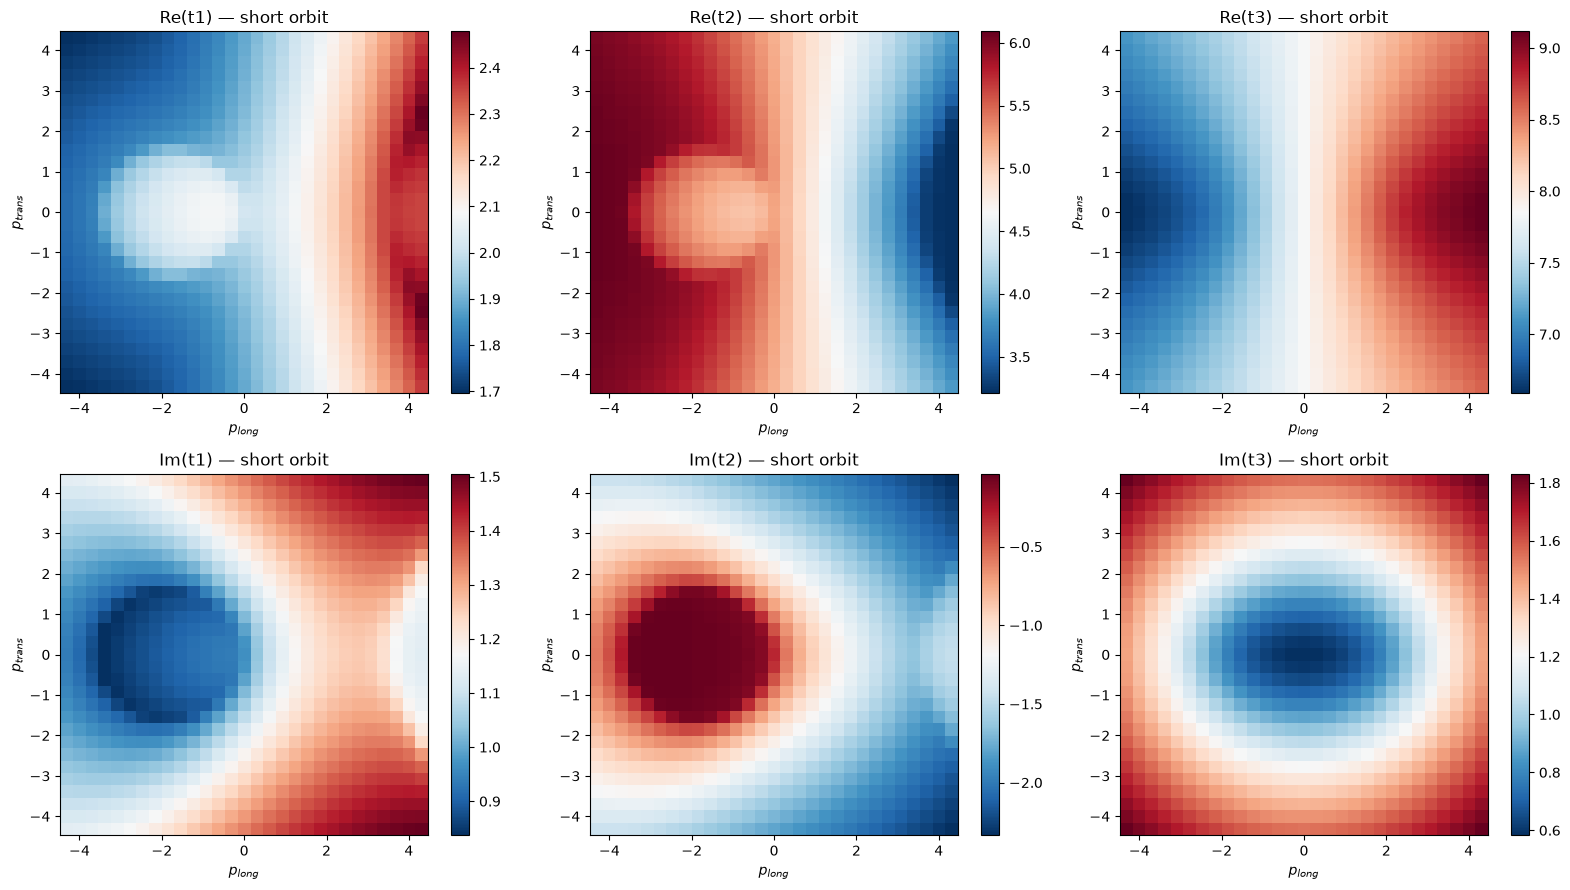

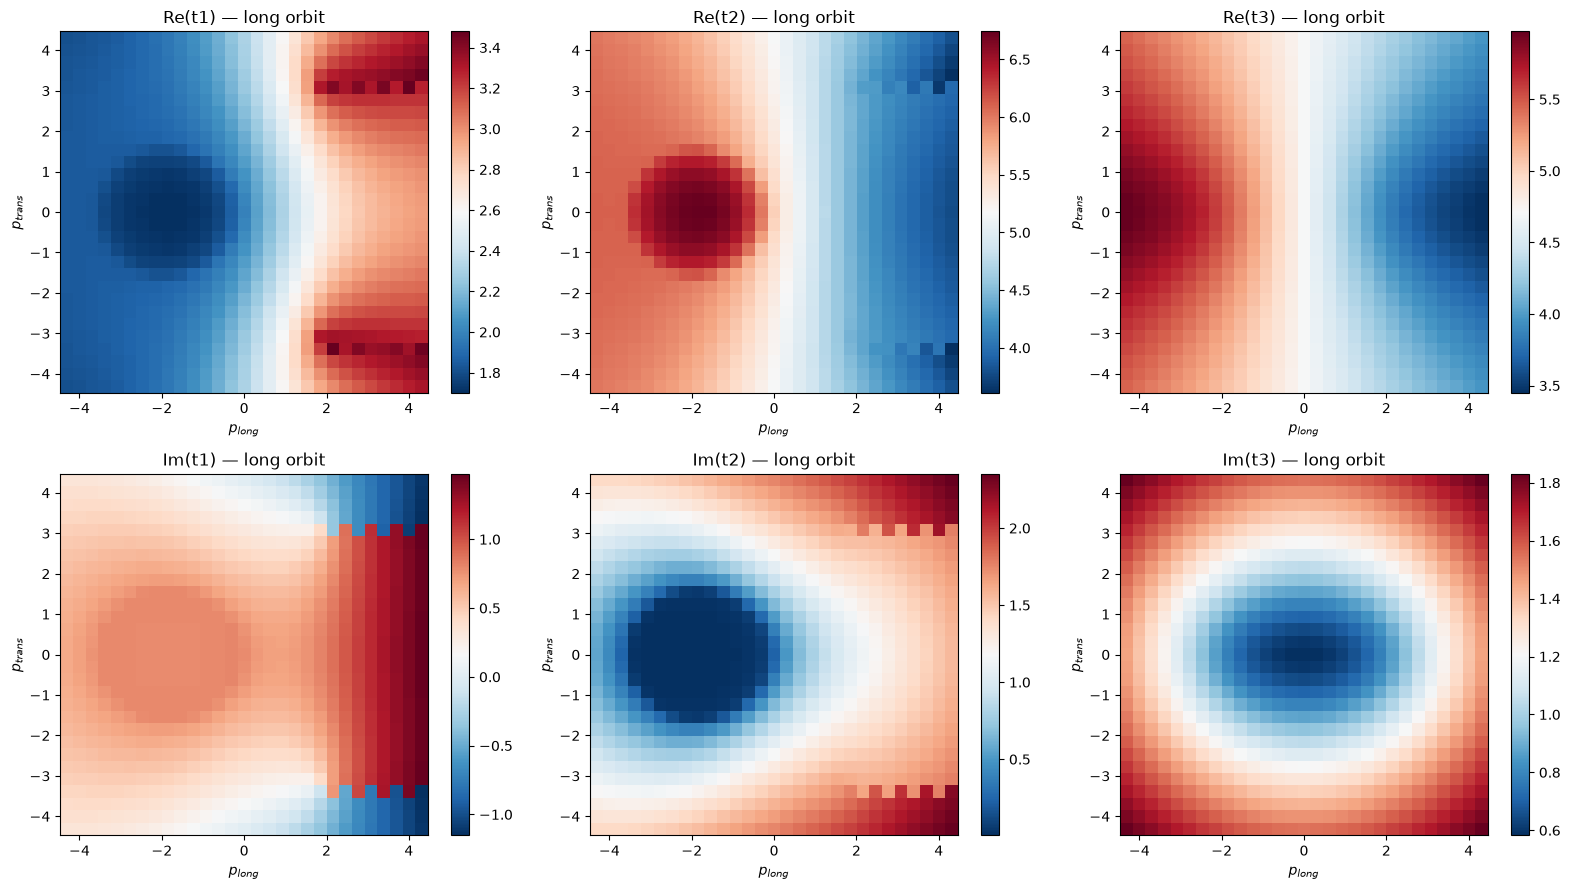

In [3]:
def bin_onto_grid(p_long, p_trans, values, decimals=3):
    long_axis = np.unique(np.round(p_long, decimals))
    trans_axis = np.unique(np.round(p_trans, decimals))
    grid = np.full((len(long_axis), len(trans_axis)), np.nan, dtype=values.dtype)
    i_idx = np.searchsorted(long_axis, np.round(p_long, decimals))
    j_idx = np.searchsorted(trans_axis, np.round(p_trans, decimals))
    grid[i_idx, j_idx] = values
    return long_axis, trans_axis, grid


def plot_2d_maps(branch_name, pl, pt, t1, t2, t3):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for col, (label, t) in enumerate([("t1", t1), ("t2", t2), ("t3", t3)]):
        long_axis, trans_axis, grid = bin_onto_grid(pl, pt, t)
        for row, (part, fn) in enumerate([("Re", np.real), ("Im", np.imag)]):
            ax = axes[row, col]
            pcm = ax.pcolormesh(long_axis, trans_axis, fn(grid).T, shading="auto", cmap="RdBu_r")
            ax.set_title(f"{part}({label}) — {branch_name}")
            ax.set_xlabel(r"$p_{long}$"); ax.set_ylabel(r"$p_{trans}$")
            fig.colorbar(pcm, ax=ax)
    plt.tight_layout()
    plt.show()


plot_2d_maps("short orbit", pl_s, pt_s, t1_s, t2_s, t3_s)
plot_2d_maps("long orbit", pl_l, pt_l, t1_l, t2_l, t3_l)